# TP — Descente de gradient : trouver le minimum d'une fonction quadratique

**Jour 1 — chapitre 04 : Sous le capot des algorithmes (régression linéaire, descente de gradient)**

## Mise en situation

Avant d'appliquer la descente de gradient à une vraie fonction de coût de régression
(diapos 24-26), on la met en œuvre ici sur un exemple simple et entièrement
visualisable : une fonction quadratique à une seule variable. L'objectif est de
comprendre mécaniquement comment l'algorithme progresse vers un minimum, et l'effet du
taux d'apprentissage `α` — avant de retrouver exactement le même mécanisme sur une vraie
fonction de coût de régression linéaire en fin de TP.

## Étape 1 — Une fonction quadratique et son minimum

**Question de réflexion :** sans calcul, à l'œil, où se situe le minimum de
f(x) = (x - 3)² + 2 ? Comment le retrouver algorithmiquement, sans résoudre f'(x) = 0 à
la main ?

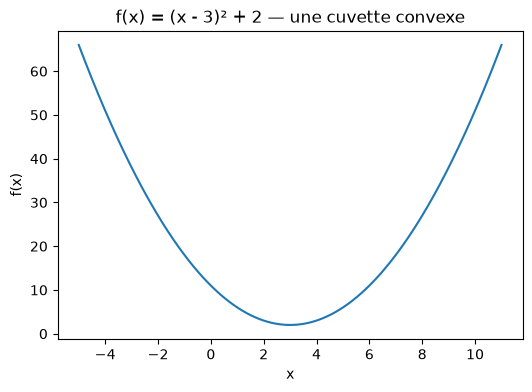

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (x - 3) ** 2 + 2

def df(x):
    # derivee de (x - 3)^2 + 2, calculee a la main : f'(x) = 2 * (x - 3)
    return 2 * (x - 3)

x_range = np.linspace(-5, 11, 200)

fig_fonction, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_range, f(x_range))
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("f(x) = (x - 3)² + 2 — une cuvette convexe")
plt.show()

**Ce qu'on observe** : comme la fonction de coût de la régression linéaire (diapo 23),
cette fonction a la forme d'une cuvette convexe — un seul minimum global, ici en x = 3.
Sur cet exemple on le voit à l'œil, mais ce ne sera plus possible dès qu'on aura
plusieurs paramètres (étape 4) : il faut un algorithme pour le trouver.

## Étape 2 — Implémenter la descente de gradient

**Question de réflexion :** en reprenant le pseudo-code de la diapo 26
(`theta = theta - alpha * gradient`), comment l'adapter pour notre fonction f ?

In [29]:
x = 10.0  # initialisation arbitraire, loin du minimum
alpha = 1
n_iterations = 30

historique_x = [x]
for iteration in range(n_iterations):
    grad = df(x)
    x = x - alpha * grad
    historique_x.append(x)

print("Point de départ :", historique_x[0])
print(f"Point trouvé après {n_iterations} itérations :", round(x, 4))
print("f(x) au point trouvé :", round(f(x), 4))

Point de départ : 10.0
Point trouvé après 30 itérations : 10.0
f(x) au point trouvé : 51.0


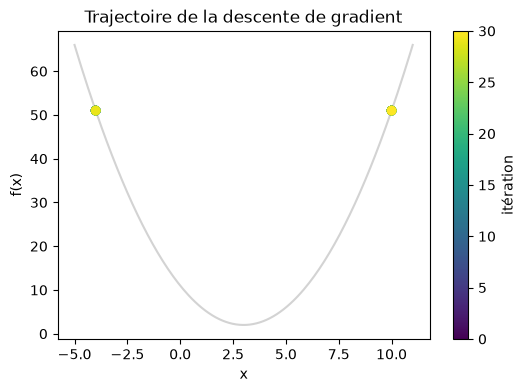

In [30]:
historique_x = np.array(historique_x)

fig_trajectoire, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_range, f(x_range), color="lightgray", zorder=1)
sc = ax.scatter(historique_x, f(historique_x), c=range(len(historique_x)), cmap="viridis", zorder=2)
fig_trajectoire.colorbar(sc, label="itération")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Trajectoire de la descente de gradient")
plt.show()

**Ce qu'on observe** : chaque point représente une itération. La valeur de x se
rapproche progressivement du minimum, avec des pas qui rétrécissent naturellement à
mesure que le gradient (la pente) s'aplatit près du minimum — exactement le mécanisme
décrit à la diapo 26.

**Et en animé ?** La cellule suivante rejoue la même trajectoire pas à pas, sous forme
de gif, pour un rendu plus parlant en présentation.

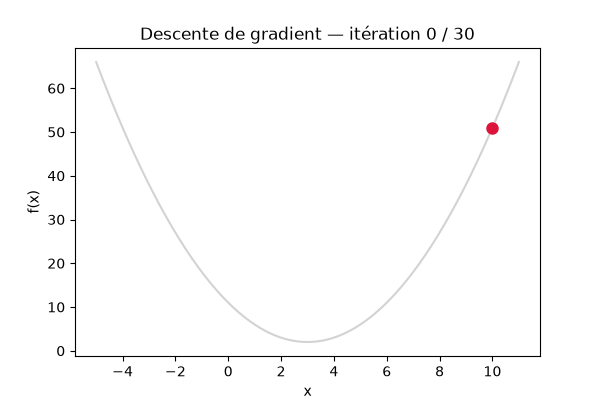

In [31]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

fig_anim, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_range, f(x_range), color="lightgray")
point_anim, = ax.plot([], [], "o", color="crimson", markersize=8)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")

def animer(frame):
    point_anim.set_data([historique_x[frame]], [f(historique_x[frame])])
    ax.set_title(f"Descente de gradient — itération {frame} / {len(historique_x) - 1}")
    return point_anim,

anim_1d = FuncAnimation(fig_anim, animer, frames=len(historique_x), interval=200, blit=True)
anim_1d.save("descente_gradient_1d.gif", writer=PillowWriter(fps=5))
plt.close(fig_anim)

Image("descente_gradient_1d.gif")

## Étape 3 — Effet du taux d'apprentissage α

**Question de réflexion :** la diapo 26 distingue trois cas pour α (trop petit / trop
grand / bien choisi). Comment les observer concrètement sur cette fonction ?

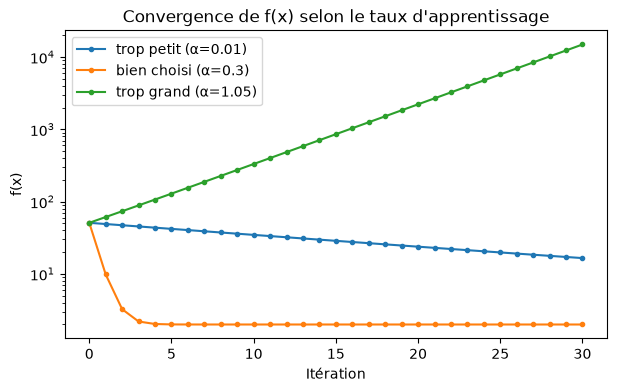

In [32]:
def descente_gradient(alpha, x_init=10.0, n_iterations=30):
    x = x_init
    historique = [f(x)]
    for _ in range(n_iterations):
        x = x - alpha * df(x)
        historique.append(f(x))
    return historique

alphas_a_tester = {
    "trop petit (α=0.01)": 0.01,
    "bien choisi (α=0.3)": 0.3,
    "trop grand (α=1.05)": 1.05,
}

fig_alpha, ax = plt.subplots(figsize=(7, 4))
for label, alpha in alphas_a_tester.items():
    ax.plot(descente_gradient(alpha), marker="o", markersize=3, label=label)
ax.set_xlabel("Itération")
ax.set_ylabel("f(x)")
ax.set_yscale("log")
ax.set_title("Convergence de f(x) selon le taux d'apprentissage")
ax.legend()
plt.show()

**Ce qu'on observe** : avec α trop petit, f(x) décroît mais très lentement — après 30
itérations on est encore loin du minimum. Avec α bien choisi, la convergence est rapide
et régulière. Avec α trop grand, f(x) augmente au lieu de diminuer : c'est la divergence
évoquée à la diapo 26 (la courbe monte en ligne quasi droite sur cette échelle
logarithmique).

## Étape 4 — Lien avec une vraie fonction de coût : la régression linéaire

**Question de réflexion :** la diapo 24 construit J(θ) = (1/2m)·Σ(hθ(xᵢ) − yᵢ)² pour la
régression linéaire. En quoi cette fonction a-t-elle la même forme que celle utilisée
ci-dessus ?

In [33]:
# Jeu de donnees synthetique simple : y = 2x + 1 + bruit
rng = np.random.default_rng(42)
x_data = rng.uniform(0, 5, size=50)
y_data = 2 * x_data + 1 + rng.normal(0, 0.5, size=50)

def cout(theta0, theta1):
    predictions = theta0 + theta1 * x_data
    return np.mean((predictions - y_data) ** 2) / 2

# Grille de valeurs pour visualiser la cuvette de J(theta0, theta1)
theta0_grid = np.linspace(-2, 4, 80)
theta1_grid = np.linspace(-1, 5, 80)
T0, T1 = np.meshgrid(theta0_grid, theta1_grid)
J = np.array([[cout(t0, t1) for t0 in theta0_grid] for t1 in theta1_grid])

import plotly.graph_objects as go

fig_cout = go.Figure(data=[go.Surface(
    x=T0, y=T1, z=J, colorscale="Viridis", showscale=True,
    colorbar=dict(title="J(θ₀, θ₁)"),
)])
fig_cout.update_layout(
    title="Fonction de coût de la régression linéaire — une cuvette convexe à 2 paramètres",
    scene=dict(
        xaxis_title="θ₀ (ordonnée à l'origine)",
        yaxis_title="θ₁ (pente)",
        zaxis_title="J(θ₀, θ₁)",
    ),
    width=750, height=550,
)
fig_cout.show()

**Ce qu'on observe** : même avec deux paramètres (θ₀ et θ₁), J garde la forme d'une
cuvette convexe unique — exactement le même principe que la fonction f(x) du début,
avec un paramètre de plus. C'est pour cela que la descente de gradient fonctionne de la
même façon, quel que soit le nombre de paramètres. Le graphique est interactif : on peut
le faire pivoter à la souris pour bien voir la forme de la cuvette sous tous les angles.

## Étape 5 — Descente de gradient sur cette vraie fonction de coût

**Question de réflexion :** quelles sont les dérivées partielles de J par rapport à θ₀
et θ₁ (diapo 25) ?

In [34]:
def gradients(theta0, theta1):
    predictions = theta0 + theta1 * x_data
    erreur = predictions - y_data
    grad_theta0 = np.mean(erreur)
    grad_theta1 = np.mean(erreur * x_data)
    return grad_theta0, grad_theta1

theta0, theta1 = -1.5, 4.5  # initialisation arbitraire, loin de la vraie relation (theta0=1, theta1=2)
alpha = 0.2
n_iterations = 500

trajectoire = [(theta0, theta1)]
for _ in range(n_iterations):
    g0, g1 = gradients(theta0, theta1)
    theta0 = theta0 - alpha * g0
    theta1 = theta1 - alpha * g1
    trajectoire.append((theta0, theta1))

print(f"theta0 trouvé : {theta0:.3f} (valeur utilisée pour générer les données : 1)")
print(f"theta1 trouvé : {theta1:.3f} (valeur utilisée pour générer les données : 2)")

theta0 trouvé : 0.884 (valeur utilisée pour générer les données : 1)
theta1 trouvé : 2.012 (valeur utilisée pour générer les données : 2)


In [35]:
trajectoire = np.array(trajectoire)
cout_trajectoire = np.array([cout(t0, t1) for t0, t1 in trajectoire])

fig_trajectoire_3d = go.Figure(data=[
    go.Surface(x=T0, y=T1, z=J, colorscale="Viridis", opacity=0.85, showscale=True,
               colorbar=dict(title="J(θ₀, θ₁)")),
    go.Scatter3d(x=trajectoire[:, 0], y=trajectoire[:, 1], z=cout_trajectoire,
                 mode="lines+markers", line=dict(color="white", width=4),
                 marker=dict(size=2, color="white"), name="Trajectoire"),
    go.Scatter3d(x=[trajectoire[0, 0]], y=[trajectoire[0, 1]], z=[cout_trajectoire[0]],
                 mode="markers", marker=dict(size=6, color="red"), name="Départ"),
    go.Scatter3d(x=[trajectoire[-1, 0]], y=[trajectoire[-1, 1]], z=[cout_trajectoire[-1]],
                 mode="markers", marker=dict(size=6, color="orange"), name="Arrivée"),
])
fig_trajectoire_3d.update_layout(
    title="Trajectoire de la descente de gradient sur J(θ₀, θ₁)",
    scene=dict(xaxis_title="θ₀", yaxis_title="θ₁", zaxis_title="J(θ₀, θ₁)"),
    width=750, height=550,
)
fig_trajectoire_3d.show()

**Ce qu'on observe** : la trajectoire part du point d'initialisation et descend
directement vers le fond de la cuvette, là où θ₀ et θ₁ se rapprochent des valeurs
utilisées pour générer les données (1 et 2). C'est exactement ce mécanisme qui se cache
derrière `LinearRegression().fit()` de scikit-learn.

**Pour aller plus loin** : ici, chaque mise à jour utilise l'ensemble des 50 points
(`np.mean` sur tout `x_data`) — c'est la version *batch* de la descente de gradient
(diapo 27). Sur de gros volumes, on utiliserait plutôt une version *stochastique* (une
observation à la fois) ou *mini-batch* (un petit sous-ensemble), pour un compromis entre
vitesse et stabilité.

**Et en animé ?** Même principe qu'à l'étape 2, appliqué cette fois à la trajectoire
dans l'espace (θ₀, θ₁) — le point converge visiblement vers le fond de la cuvette.
Contrairement au gif de l'étape 2, ce graphique Plotly reste interactif pendant la
lecture : on peut le faire pivoter, zoomer, et avancer manuellement avec le curseur.

In [36]:
# On echantillonne les iterations pour garder l'animation legere
frames_a_afficher = list(range(0, len(trajectoire), 10)) + [len(trajectoire) - 1]

surface_trace = go.Surface(x=T0, y=T1, z=J, colorscale="Viridis", opacity=0.85,
                            showscale=True, colorbar=dict(title="J(θ₀, θ₁)"))

def trace_position(i):
    return go.Scatter3d(
        x=trajectoire[:i + 1, 0], y=trajectoire[:i + 1, 1], z=cout_trajectoire[:i + 1],
        mode="lines+markers",
        line=dict(color="white", width=4),
        marker=dict(size=3, color="red"),
        name="Descente de gradient",
    )

fig_anim_plotly = go.Figure(
    data=[surface_trace, trace_position(0)],
    # traces=[1] : seule la trace de trajectoire (index 1) est mise a jour a chaque
    # frame, la surface (index 0) reste inchangee - evite de la redupliquer partout.
    frames=[go.Frame(data=[trace_position(i)], traces=[1], name=str(i)) for i in frames_a_afficher],
)

fig_anim_plotly.update_layout(
    title="Descente de gradient sur J(θ₀, θ₁) — cliquez sur ▶ Play",
    scene=dict(xaxis_title="θ₀", yaxis_title="θ₁", zaxis_title="J(θ₀, θ₁)"),
    width=750, height=600,
    updatemenus=[dict(
        type="buttons",
        buttons=[
            dict(label="▶ Play", method="animate",
                 args=[None, {"frame": {"duration": 150, "redraw": True}, "fromcurrent": True}]),
            dict(label="⏸ Pause", method="animate",
                 args=[[None], {"frame": {"duration": 0}, "mode": "immediate"}]),
        ],
    )],
    sliders=[dict(
        currentvalue={"prefix": "Itération : "},
        steps=[
            dict(method="animate", label=str(i),
                 args=[[str(i)], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}])
            for i in frames_a_afficher
        ],
    )],
)

fig_anim_plotly.show()

**Et si on change α ?** Comme à l'étape 3, le taux d'apprentissage change fortement le
comportement de la descente — y compris ici, sur la vraie fonction de coût à deux
paramètres. Le graphique suivant précalcule plusieurs trajectoires et laisse choisir α
dans un menu déroulant, sans avoir à relancer de cellule.

In [37]:
alphas_a_comparer = [0.02, 0.1, 0.19, 0.205]
n_iterations_comparaison = 150

trajectoires_par_alpha = {}
for a in alphas_a_comparer:
    t0, t1 = -1.5, 4.5
    traj = [(t0, t1)]
    for _ in range(n_iterations_comparaison):
        g0, g1 = gradients(t0, t1)
        t0 = t0 - a * g0
        t1 = t1 - a * g1
        traj.append((t0, t1))
    traj = np.array(traj)
    cout_traj = np.array([cout(x, y) for x, y in traj])
    trajectoires_par_alpha[a] = (traj, cout_traj)

fig_comparaison_alpha = go.Figure()
fig_comparaison_alpha.add_trace(go.Surface(
    x=T0, y=T1, z=J, colorscale="Viridis", opacity=0.85,
    showscale=True, colorbar=dict(title="J(θ₀, θ₁)"),
))

# Une trace de trajectoire par alpha ; seule celle du premier alpha est visible au depart.
for i, a in enumerate(alphas_a_comparer):
    traj, cout_traj = trajectoires_par_alpha[a]
    fig_comparaison_alpha.add_trace(go.Scatter3d(
        x=traj[:, 0], y=traj[:, 1], z=cout_traj,
        mode="lines+markers", line=dict(color="white", width=4),
        marker=dict(size=2, color="red"),
        name=f"α = {a}", visible=(i == 0),
    ))

# Un bouton par alpha : rend visible sa seule trace de trajectoire (index i+1) et
# cache les autres, sans toucher a la surface (index 0) ni recalculer quoi que ce soit.
boutons_alpha = []
for i, a in enumerate(alphas_a_comparer):
    traj, _ = trajectoires_par_alpha[a]
    visibilite = [True] + [j == i for j in range(len(alphas_a_comparer))]
    boutons_alpha.append(dict(
        label=f"α = {a}",
        method="update",
        args=[
            {"visible": visibilite},
            {"title": (f"Descente de gradient — α = {a} "
                       f"(θ₀ final = {traj[-1, 0]:.2f}, θ₁ final = {traj[-1, 1]:.2f})")},
        ],
    ))

fig_comparaison_alpha.update_layout(
    title=f"Descente de gradient — α = {alphas_a_comparer[0]}",
    scene=dict(
        xaxis=dict(title="θ₀", range=[-2, 4]),
        yaxis=dict(title="θ₁", range=[-1, 5]),
        zaxis=dict(title="J(θ₀, θ₁)", range=[0, 25]),
    ),
    width=750, height=600,
    updatemenus=[dict(
        type="dropdown", buttons=boutons_alpha,
        x=0.02, y=1.05, xanchor="left", yanchor="top",
    )],
)

fig_comparaison_alpha.show()

**Ce qu'on observe** : avec α = 0.02, la trajectoire est encore loin du minimum après
150 itérations — trop lent. Avec α = 0.1 ou 0.19, la descente converge proprement vers
le fond de la cuvette. Avec α = 0.205, la trajectoire sort du cadre visible : elle
diverge, car ce problème a une limite de stabilité théorique à α ≈ 0.202 pour ce jeu de
données (au-delà, chaque pas s'éloigne un peu plus du minimum au lieu de s'en
rapprocher) — exactement le cas « α trop grand » de la diapo 26, ici sur un vrai
problème à deux paramètres plutôt que sur la fonction jouet de l'étape 1.

## Étape 6 — Vérification avec scikit-learn

**Question de réflexion :** si on utilise `LinearRegression` de scikit-learn sur les
mêmes données, retrouve-t-on les mêmes coefficients ?

In [ ]:
from sklearn.linear_model import LinearRegression

modele_sklearn = LinearRegression()
modele_sklearn.fit(x_data.reshape(-1, 1), y_data)

print("scikit-learn   — θ₀ (intercept) :", round(modele_sklearn.intercept_, 3))
print("scikit-learn   — θ₁ (coefficient) :", round(modele_sklearn.coef_[0], 3))
print()
print("Notre descente — θ₀ :", round(theta0, 3))
print("Notre descente — θ₁ :", round(theta1, 3))

**Ce qu'on observe** : les deux méthodes convergent vers des coefficients très
proches. scikit-learn utilise en interne une résolution optimisée plutôt qu'une
descente de gradient pas à pas comme la nôtre, mais l'objectif — minimiser la même
fonction de coût convexe — est rigoureusement identique.

**À retenir pour le débriefing du TP** : ce mécanisme (fonction de coût convexe →
dérivée → mise à jour itérative des paramètres) est celui qui se cache derrière
`.fit()`, aussi bien pour la régression linéaire que pour la régression logistique vue
juste après (diapos 28-30). Le taux d'apprentissage α reste le même hyperparamètre
sensible dans les deux cas.